# Hospital Financial Distress Prediction
This notebook documents the process of building a model to predict financial status for acute care facilities using 5 years of CMS Medicare Cost Reports (2019-2023)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, warnings

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Data Loading 

In [2]:
df = pd.concat([
    pd.read_csv(f'data/CostReport_{year}_Final.csv').assign(Year=year)
    for year in range(2019, 2024)
], ignore_index=True)

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (30400, 118)


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Year
0,650479,201302,LINCOLNHEALTH,6 ST. ANDREWS LANE,BOOTHBAY HARBOR,ME,04538-,LINCOLN,99920.0,R,CAH,1,2,10/01/2018,12/31/2018,362.19,NaN,NaN,820.0,126.0,1793.0,25.0,9125.0,NaN,187.0,33.0,382.0,67.0,NaN,690.0,80.0,1377.0,21.0,7665.0,NaN,187.0,33.0,382.0,259986.0,1047204.0,851792.0,851792.0,6124146.0,15117362.0,928865.0,18206588.0,9440440.0,21196720.0,30637160.0,NaN,NaN,NaN,NaN,NaN,NaN,4425475.0,NaN,591564.0,6985850.0,NaN,3294397.0,NaN,NaN,23717347.0,2480754.0,5779808.0,62333238.0,630254.0,8436081.0,22873561.0,NaN,NaN,46762120.0,12633553.0,3335454.0,15969007.0,86448474.0,1617780.0,2630412.0,NaN,NaN,17032.0,1971307.0,17186883.0,NaN,9448243.0,NaN,3303566.0,12751809.0,29938692.0,56509782.0,56509782.0,86448474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10567431.0,23595634.0,34163065.0,12768843.0,21394222.0,21973982.0,-579760.0,61805.0,-517955.0,NaN,-517955.0,0.594265,1692896.0,2

In [3]:
# Create lists of potential features to improve output readability
facility_cols = [
    'Rural Versus Urban',
    'CCN Facility Type',
    'Provider Type',
    'Type of Control'
]

bed_cols = [
    'Number of Beds',
    'Number of Beds + Total for all Subproviders',
    'Hospital Number of Beds For Adults & Peds',
]

patient_cols = [
    'Total Days Title V',
    'Hospital Total Days Title V For Adults & Peds',
    'Total Days Title XVIII',
    'Hospital Total Days Title XVIII For Adults & Peds',
    'Total Days Title XIX',
    'Hospital Total Days Title XIX For Adults & Peds',
    'Total Days (V + XVIII + XIX + Unknown)',
    'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds',
    'Total Bed Days Available',
    'Hospital Total Bed Days Available For Adults & Peds',
    'Total Discharges Title V',
    'Hospital Total Discharges Title V For Adults & Peds',
    'Total Discharges Title XVIII',
    'Hospital Total Discharges Title XVIII For Adults & Peds',
    'Total Discharges Title XIX',
    'Hospital Total Discharges Title XIX For Adults & Peds',
    'Total Discharges (V + XVIII + XIX + Unknown)',
    'Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds'    
]

financial_cols = [
    # Loss due to uncompensated care
    'Cost of Charity Care',
    'Total Bad Debt Expense',
    'Cost of Uncompensated Care',
    'Total Unreimbursed and Uncompensated Care',

    # Charges and Revenue options
    'Combined Outpatient + Inpatient Total Charges',
    'Total Patient Revenue',
    'Cash on Hand and in Banks',
    'Total Costs',
    'Cost To Charge Ratio',
    'Inventory',
    'Contract Labor: Direct Patient Care',
    'Total Assets',
    'Total Liabilities',
    

    # Target
    'Net Income'
]



identifier_cols = [
    'Year',
    'Hospital Name',
    'City',
    'State Code',
]

df[identifier_cols].isnull().sum()

Year             0
Hospital Name    0
City             0
State Code       0
dtype: int64

#### Evaluation of Facility Information Data

In [4]:
for col in facility_cols:
    print(df[col].value_counts())
    print()

Rural Versus Urban
U    17142
R    12872
Name: count, dtype: int64

CCN Facility Type
STH      16331
CAH       6876
PH        3146
LTCH      1765
RH        1716
CH         466
RNMHC       58
ORD         41
TC           1
Name: count, dtype: int64

Provider Type
1     23099
4      3082
2      1771
5      1745
7       407
9       152
3        62
6        54
12       18
10        6
11        4
Name: count, dtype: int64

Type of Control
2     12200
4      7154
1      2991
9      1881
11     1710
5      1279
10     1176
6       551
8       415
13      388
12      320
7       220
3       115
Name: count, dtype: int64



In [5]:
# Checking for mislabeled facilities before removing non-acute care categories
pd.crosstab(df['Provider Type'], df['CCN Facility Type'])

CCN Facility Type,CAH,CH,LTCH,ORD,PH,RH,RNMHC,STH,TC
Provider Type,,,,,,,,,
1,6762,27,1,41,27,2,2,16236,1
2,0,9,1754,0,4,1,1,2,0
3,0,3,0,0,1,1,0,57,0
4,0,4,0,0,3075,0,1,2,0
5,0,13,4,0,12,1712,2,2,0
6,0,1,0,0,2,0,51,0,0
7,0,398,0,0,9,0,0,0,0
9,112,11,1,0,16,0,1,11,0
10,1,0,5,0,0,0,0,0,0


In [6]:
# Reduce dataset to only acute-care hospitals based on CCN Facility type, children's hospitals omitted due to small sample size
df = df[df['CCN Facility Type'].isin(['STH', 'CAH'])]
df.shape

(23207, 118)

In [7]:
df[df['Rural Versus Urban'].isnull()]['CCN Facility Type'].value_counts()

CCN Facility Type
STH    42
Name: count, dtype: int64

#### Evaluation of Facility Capacity Data

In [8]:
df[bed_cols].isnull().sum()

Number of Beds                                  99
Number of Beds + Total for all Subproviders     77
Hospital Number of Beds For Adults & Peds      112
dtype: int64

In [9]:
df[bed_cols].describe().round(2)

,Number of Beds,Number of Beds + Total for all Subproviders,Hospital Number of Beds For Adults & Peds
count,23108.00,23130.00,23095.00
mean,225.16,246.54,194.16
std,10542.33,10537.83,10501.72
min,1.00,1.00,1.00
25%,25.00,25.00,25.00
50%,67.00,89.00,59.00
75%,196.00,222.75,167.00
max,1594784.00,1594796.00,1594778.00


In [10]:
# At the time of this project published public information states New York Presbyterian Weill Cornell Medical Center is the largest hospital by bed count with 2,850 beds
df[df['Number of Beds'] > 3000][identifier_cols + bed_cols].sort_values('Hospital Name')

,Year,Hospital Name,City,State Code,Number of Beds,Number of Beds + Total for all Subproviders,Hospital Number of Beds For Adults & Peds
728,2019,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,ID,52913.0,52981.0,52913.0
7582,2020,MERCY HOSPITAL & MEDICAL CENTER,CHICAGO,IL,144837.0,144892.0,132.0
4404,2019,OKLAHOMA HEART HOSPITAL,OKLAHOMA CITY,OK,28401.0,28401.0,28401.0
10337,2020,WAYNE HOSPITAL COMPANY,GREENVILLE,OH,1594784.0,1594796.0,1594778.0


In [11]:
bed_outlier_ccns = df[df['Number of Beds'] > 3000]['Provider CCN'].tolist()
df[df['Provider CCN'].isin(bed_outlier_ccns)][identifier_cols + bed_cols].sort_values(['Hospital Name', 'Year'])

,Year,Hospital Name,City,State Code,Number of Beds,Number of Beds + Total for all Subproviders,Hospital Number of Beds For Adults & Peds
728,2019,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,ID,52913.0,52981.0,52913.0
6274,2020,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,ID,21.0,89.0,21.0
12408,2021,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,ID,21.0,89.0,21.0
18895,2022,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,ID,21.0,89.0,21.0
25311,2023,BEAR LAKE MEMORIAL HOSPITAL,MONTPELIER,ID,21.0,91.0,21.0
15974,2021,INSIGHTS HOSPITAL AND MEDICAL CENTER,CHICAGO,IL,52.0,91.0,37.0
20040,2022,INSIGHTS HOSPITAL AND MEDICAL CENTER,CHICAGO,IL,52.0,91.0,37.0
26552,2023,INSIGHTS HOSPITAL AND MEDICAL CENTER,CHICAGO,IL,52.0,91.0,37.0
2895,2019,MERCY HOSPITAL & MEDICAL CENTER,CHICAGO,IL,203.0,258.0,168.0
7582,2020,MERCY HOSPITAL & MEDICAL CENTER,CHICAGO,IL,144837.0,144892.0,132.0


In [12]:
bed_diff = df['Number of Beds'] - df['Hospital Number of Beds For Adults & Peds']
print(bed_diff.describe().round(2))
print(f"\nRows where A&P beds < Total beds: {(bed_diff > 0).sum()}")
print(f"Rows where difference > 50 beds: {(bed_diff > 50).sum()}")
print(f"Rows where difference > 100 beds: {(bed_diff > 100).sum()}")
print(f"Rows where A&P beds > Total beds: {(df['Hospital Number of Beds For Adults & Peds'] > df['Number of Beds']).sum()}")
print(f"Rows where A&P beds equal Total beds: {(df['Hospital Number of Beds For Adults & Peds'] == df['Number of Beds']).sum()}")

count     23095.00
mean         31.09
std         953.25
min           0.00
25%           0.00
50%           8.00
75%          28.00
max      144705.00
dtype: float64

Rows where A&P beds < Total beds: 14898
Rows where difference > 50 beds: 3360
Rows where difference > 100 beds: 1342
Rows where A&P beds > Total beds: 0
Rows where A&P beds equal Total beds: 8197


#### Evaluation of Facility Payor Data

In [13]:
df[patient_cols].isnull().sum()

Total Days Title V                                                         22587
Hospital Total Days Title V For Adults & Peds                              22664
Total Days Title XVIII                                                       243
Hospital Total Days Title XVIII For Adults & Peds                            297
Total Days Title XIX                                                        2247
Hospital Total Days Title XIX For Adults & Peds                             2597
Total Days (V + XVIII + XIX + Unknown)                                       141
Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds            153
Total Bed Days Available                                                      99
Hospital Total Bed Days Available For Adults & Peds                          109
Total Discharges Title V                                                   22630
Hospital Total Discharges Title V For Adults & Peds                        22630
Total Discharges Title XVIII

In [14]:
df[patient_cols].describe().round(2)

,Total Days Title V,Hospital Total Days Title V For Adults & Peds,Total Days Title XVIII,Hospital Total Days Title XVIII For Adults & Peds,Total Days Title XIX,Hospital Total Days Title XIX For Adults & Peds,Total Days (V + XVIII + XIX + Unknown),Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Total Bed Days Available,Hospital Total Bed Days Available For Adults & Peds,Total Discharges Title V,Hospital Total Discharges Title V For Adults & Peds,Total Discharges Title XVIII,Hospital Total Discharges Title XVIII For Adults & Peds,Total Discharges Title XIX,Hospital Total Discharges Title XIX For Adults & Peds,Total Discharges (V + XVIII + XIX + Unknown),Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds
count,620.00,543.00,22964.00,22910.00,20960.00,20610.00,23066.00,23054.00,23108.00,23098.00,577.00,577.00,22995.00,22995.00,20579.00,20579.00,23061.00,23061.00
mean,2003.32,1232.34,8873.73,7389.91,3438.85,2420.81,33483.02,25742.83,52680.46,43771.57,431.81,431.81,1647.45,1647.45,611.27,611.27,6536.58,6536.58
std,3320.56,2438.04,13753.55,11842.44,7861.50,5729.02,55159.95,42200.63,70634.14,55855.85,618.17,618.17,2363.54,2363.54,1335.14,1335.14,9860.07,9860.07
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,26.00,26.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,99.75,17.50,1043.00,549.00,109.75,67.00,2579.00,1365.25,9125.00,9125.00,15.00,15.00,164.00,164.00,25.00,25.00,442.00,442.00
50%,669.50,178.00,2868.50,2158.00,715.00,456.00,9565.00,7353.00,23725.00,20496.00,171.00,171.00,610.00,610.00,141.00,141.00,2307.00,2307.00
75%,2638.50,1659.00,11483.50,9831.75,3216.25,2134.00,43522.75,34749.00,70653.25,60225.00,603.00,603.00,2290.00,2290.00,591.00,591.00,9194.00,9194.00
max,21043.00,21003.00,208248.00,177055.00,139073.00,101131.00,911866.00,689552.00,1040250.00,844610.00,3597.00,3597.00,31284.00,31284.00,19799.00,19799.00,168398.00,168398.00


In [15]:
df[df['Total Days Title XIX'].isnull()]['CCN Facility Type'].value_counts()

CCN Facility Type
CAH    1158
STH    1089
Name: count, dtype: int64

In [16]:
df[df['Hospital Total Days Title XIX For Adults & Peds'].isnull()]['CCN Facility Type'].value_counts()

CCN Facility Type
CAH    1418
STH    1179
Name: count, dtype: int64

In [17]:
df[df['Total Days Title XIX'].isnull()].groupby(['Hospital Name'])['Year'].count().sort_values(ascending=False).head(20)

Hospital Name
JEFFERSON COUNTY HOSPITAL              6
HEMPHILL COUNTY HOSPITAL               6
FALLS COMMUNITY HOSPITAL AND CLINIC    6
PHYSICIANS CARE SURGICAL HOSPITAL      6
SHAMROCK GENERAL HOSPITAL              6
SEDAN CITY HOSPITAL                    6
PETALUMA VALLEY HOSPITAL               6
OUR LADY OF THE LAKE ASSUMPTION COM    6
GUTTENBERG MUNICIPAL HOSPITAL          5
WAMEGO HOSPITAL ASSOCIATION            5
WILMINGTON TREATMENT CENTER INC        5
HIRAM W DAVIS MEDICAL CENTER - MS      5
INCLINE VILLAGE HOSPITAL               5
WISE HEALTH SYSTEM - PARKWAY           5
ASPIRE HOSPITAL  LLC                   5
AZ SPINE & JOINT HOSPITAL              5
TOPS SURGICAL SPECIALTY HOSPITAL       5
GRACEVILLE HEALTH CENTER               5
GRAPE COMMUNITY HOSPITAL - HAMBURG     5
GREAT PLAINS OF ELLINWOOD  INC.        5
Name: Year, dtype: int64

In [18]:
df[df['Hospital Total Days Title XIX For Adults & Peds'].isnull()].groupby(['Hospital Name'])['Year'].count().sort_values(ascending=False).head(20)

Hospital Name
WASHINGTON COUNTY HOSPITAL              9
JEFFERSON COUNTY HOSPITAL               7
HEMPHILL COUNTY HOSPITAL                6
SEDAN CITY HOSPITAL                     6
SHAMROCK GENERAL HOSPITAL               6
OUR LADY OF THE LAKE ASSUMPTION COM     6
PETALUMA VALLEY HOSPITAL                6
PHYSICIANS CARE SURGICAL HOSPITAL       6
FALLS COMMUNITY HOSPITAL AND CLINIC     6
THROCKMORTON COUNTY HOSPITAL            5
TOPS SURGICAL SPECIALTY HOSPITAL        5
TREGO COUNTY LEMKE MEMORIAL HOSPITAL    5
ADMIN DE SERVICIOS MEDICOS DE PR        5
HEBREW HOME & HOSPITAL                  5
HAZEL HAWKINS MEM. HOSPITAL             5
INCLINE VILLAGE HOSPITAL                5
IRAAN GENERAL HOSPITAL DISTRICT         5
KANSAS MEDICAL CENTER                   5
KANSAS SURGERY & RECOVERY CENTER        5
HALE HOOLA HAMAKUA                      5
Name: Year, dtype: int64

In [19]:
df['avg_los'] = (df['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds'] / 
                     df['Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds'])

df[df['avg_los'] > 365][['Hospital Name', 'State Code', 'Year', 'CCN Facility Type', 'avg_los']].sort_values('avg_los', ascending=False).head(20)

,Hospital Name,State Code,Year,CCN Facility Type,avg_los
16692,TERENCE CARDINAL COOKE HEALTH CARE,NY,2021,STH,20564.000000
19250,TERENCE CARDINAL COOKE HEALTH CARE,NY,2022,STH,2917.857143
25887,TERENCE CARDINAL COOKE HEALTH CARE,NY,2023,STH,2552.375000
9577,TERENCE CARDINAL COOKE HEALTH CARE,NY,2020,STH,2282.888889
7230,FLORIDA STATE HOSPITAL,FL,2020,STH,615.000000


In [20]:
df[df['Hospital Name'].isin(['TERENCE CARDINAL COOKE HEALTH CARE', 'FLORIDA STATE HOSPITAL'])][
    ['Hospital Name', 'Year', 'CCN Facility Type', 'avg_los']
].sort_values(['Hospital Name', 'Year'])

,Hospital Name,Year,CCN Facility Type,avg_los
951,FLORIDA STATE HOSPITAL,2019,STH,NaN
7230,FLORIDA STATE HOSPITAL,2020,STH,615.000000
14382,FLORIDA STATE HOSPITAL,2021,STH,NaN
22854,FLORIDA STATE HOSPITAL,2022,STH,NaN
29634,FLORIDA STATE HOSPITAL,2023,STH,139.071429
9577,TERENCE CARDINAL COOKE HEALTH CARE,2020,STH,2282.888889
16692,TERENCE CARDINAL COOKE HEALTH CARE,2021,STH,20564.000000
19250,TERENCE CARDINAL COOKE HEALTH CARE,2022,STH,2917.857143
25887,TERENCE CARDINAL COOKE HEALTH CARE,2023,STH,2552.375000


In [21]:
# remove temp column created for evaluating data
df.drop(columns=['avg_los'], inplace=True)

#### Evaluation of Facility Financial Data

In [22]:
df[financial_cols].isnull().sum()

Cost of Charity Care                             1872
Total Bad Debt Expense                            839
Cost of Uncompensated Care                        700
Total Unreimbursed and Uncompensated Care         589
Combined Outpatient + Inpatient Total Charges      46
Total Patient Revenue                             417
Cash on Hand and in Banks                         985
Total Costs                                        42
Cost To Charge Ratio                              283
Inventory                                        1708
Contract Labor: Direct Patient Care              9135
Total Assets                                      583
Total Liabilities                                 614
Net Income                                         69
dtype: int64

In [23]:
df[financial_cols].describe().round(2)

,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Combined Outpatient + Inpatient Total Charges,Total Patient Revenue,Cash on Hand and in Banks,Total Costs,Cost To Charge Ratio,Inventory,Contract Labor: Direct Patient Care,Total Assets,Total Liabilities,Net Income
count,2.133500e+04,2.236800e+04,2.250700e+04,2.261800e+04,2.316100e+04,2.279000e+04,2.222200e+04,2.316500e+04,22924.00,2.149900e+04,1.407200e+04,2.262400e+04,2.259300e+04,2.313800e+04
mean,6.590018e+06,1.167926e+07,8.982960e+06,1.669356e+07,9.748674e+08,1.012740e+09,2.981397e+07,2.054141e+08,135.03,5.276733e+06,9.478204e+06,3.979762e+08,1.676732e+08,1.678241e+07
std,2.018160e+07,2.351902e+07,2.365844e+07,4.212285e+07,1.899483e+09,1.953218e+09,1.553942e+08,3.720474e+08,20300.91,1.818641e+07,2.014805e+07,1.578917e+09,1.112180e+09,1.107138e+08
min,1.000000e+00,-9.501520e+05,-1.569430e+05,-2.482000e+03,1.000000e+00,1.000000e+00,-3.253155e+09,3.203980e+05,0.00,-1.297701e+09,1.000000e+02,-1.341894e+09,-4.727631e+09,-3.955820e+09
25%,3.432405e+05,1.341643e+06,1.031350e+06,1.835547e+06,6.515195e+07,7.197615e+07,4.611825e+04,2.756501e+07,0.19,5.768465e+05,7.989565e+05,2.963294e+07,8.481427e+06,-1.220716e+06
50%,1.613112e+06,4.399835e+06,2.933747e+06,5.442197e+06,2.835874e+08,3.076616e+08,3.019452e+06,7.687445e+07,0.29,1.958561e+06,2.883786e+06,8.830399e+07,3.076726e+07,2.996085e+06
75%,5.699473e+06,1.288915e+07,8.411020e+06,1.644761e+07,1.122828e+09,1.177710e+09,1.473475e+07,2.319808e+08,0.48,5.687079e+06,9.065441e+06,2.896378e+08,1.157083e+08,1.676478e+07
max,8.192046e+08,6.715466e+08,8.504827e+08,1.063928e+09,4.511504e+10,4.511504e+10,5.328738e+09,7.921780e+09,3073691.00,6.378260e+08,4.981880e+08,8.531485e+10,8.478592e+10,7.919570e+09


In [24]:
df[df['Net Income'].isnull()][identifier_cols + facility_cols].value_counts(['CCN Facility Type'])

CCN Facility Type
STH                  68
CAH                   1
Name: count, dtype: int64

### Data Cleaning List
- Use CCN Based Filter to remove non-acute care facilities from the raw data frame due to more accurate reporting.
- Exclude facilities with fewer than 365 Total Hospital Days for Adults & Peds to eliminate facilities too small to require 24/7 operation
- Drop 188 rows with null Rural Versus Urban — small number & either special status or not located within one of the 50 US states.
- Group type of control into 3 groups: Non-Profit (1-2), For-Profit (3-6), & Government (7-13)
- Drop rows 728 (Bear Lake Memorial 2019), 7582 (Mercy Hospital 2020), 4404 (Oklahoma Heart 2019), 10337 (Wayne Hospital 2020) — confirmed single-year bed count reporting errors
- Use Hospital Number of Beds For Adults & Peds instead of Number of Beds
- Use Hospital Total Days For Adults & Peds columns for payer mix and utilization ratios verified excludes subcomponents in data dictionary
- Total Discharges and Hospital Total Discharges For Adults & Peds are functionally identical per the data dictionary
- Exclude Terence Cardinal Cooke Health Care — LTC facility & Florida State Hospital — state psychiatric institution
- Revisit nulls in both Net Income and Title XIX Discharges for A&P after removing items above. Currently 215 target nulls and 2750 Title XIX A&P.


In [25]:
data = df.copy()
print(f'Shape before exclusions: {data.shape}')

data = data.dropna(subset=['Rural Versus Urban'])
data = data.drop(index=[728, 7582, 4404, 10337])
data = data[~data['Hospital Name'].isin(['TERRENCE CARDINAL COOKE HEALTH CARE', 'FLORIDA STATE HOSPITAL'])]
data = data[data['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds'] >= 365]
print(f'Shape after exclusions: {data.shape}')

Shape before exclusions: (23207, 118)
Shape after exclusions: (21091, 118)


In [26]:
print(f'Null Net Income: {data['Net Income'].isnull().sum()}')
print(f'Null Title XIX Days: {data['Total Days Title XIX'].isnull().sum()}')
print(f'Null Title XIX Days for Adults & Peds: {data['Hospital Total Days Title XIX For Adults & Peds'].isnull().sum()}')

Null Net Income: 27
Null Title XIX Days: 1354
Null Title XIX Days for Adults & Peds: 1571


In [27]:
# Drop the 27 remaining facilities with a null target
data = data.dropna(subset=['Net Income'])
print(f'Shape after dropping null Net Income: {data.shape}')

Shape after dropping null Net Income: (21064, 118)


In [28]:
print(f"Unique facilities with null Title XIX A&P: {data[data['Hospital Total Days Title XIX For Adults & Peds'].isnull()]['Provider CCN'].nunique()}")
data[data['Hospital Total Days Title XIX For Adults & Peds'].isnull()].groupby(['CCN Facility Type'])['Provider CCN'].nunique()

Unique facilities with null Title XIX A&P: 609


CCN Facility Type
CAH    271
STH    338
Name: Provider CCN, dtype: int64

In [29]:
pd.crosstab(
    data[data['Hospital Total Days Title XIX For Adults & Peds'].isnull()]['CCN Facility Type'],
    data[data['Hospital Total Days Title XIX For Adults & Peds'].isnull()]['Provider Type']
)

Provider Type,1,9
CCN Facility Type,,
CAH,635,13
STH,922,0


### Final Feature Null Analysis

In [30]:
medicare_nulls = ['Hospital Total Days Title XVIII For Adults & Peds', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds']
medicaid_nulls = ['Hospital Total Days Title XIX For Adults & Peds', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds']
bed_nulls = ['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds', 'Hospital Total Bed Days Available For Adults & Peds']
los_nulls = ['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds', 'Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds']
uncompensated_nulls = ['Total Unreimbursed and Uncompensated Care', 'Total Patient Revenue']
days_cash_on_hand_nulls = ['Cash on Hand and in Banks', 'Total Costs']
other_features = ['Cost To Charge Ratio', 'Contract Labor: Direct Patient Care', 'Inventory', 'Total Assets', 'Total Liabilities']

print(f'Medicare Nulls (medicaid_reported)')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[medicare_nulls].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[medicare_nulls].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[medicare_nulls].isnull().sum().sort_values(ascending=False))

Medicare Nulls (medicaid_reported)
Current rows: 21064
Rows with any null in required columns: 84
Percent of current data retained if rows with any null in required columns dropped: 0.9960121534371439

Hospital Total Days Title XVIII For Adults & Peds                    84
Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds     0
dtype: int64


In [31]:
print(f'Medicaid Nulls (medicaid_reported)')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[medicaid_nulls].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[medicaid_nulls].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[medicaid_nulls].isnull().sum().sort_values(ascending=False))

Medicaid Nulls (medicaid_reported)
Current rows: 21064
Rows with any null in required columns: 1570
Percent of current data retained if rows with any null in required columns dropped: 0.9254652487656665

Hospital Total Days Title XIX For Adults & Peds                      1570
Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds       0
dtype: int64


In [32]:
print(f'Bed Nulls (bed utilization reported)')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[bed_nulls].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[bed_nulls].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[bed_nulls].isnull().sum().sort_values(ascending=False))

Bed Nulls (bed utilization reported)
Current rows: 21064
Rows with any null in required columns: 1
Percent of current data retained if rows with any null in required columns dropped: 0.9999525256361564

Hospital Total Bed Days Available For Adults & Peds                  1
Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds    0
dtype: int64


In [33]:
print(f'LOS Nulls (length of stay reported)')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[los_nulls].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[los_nulls].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[los_nulls].isnull().sum().sort_values(ascending=False))

LOS Nulls (length of stay reported)
Current rows: 21064
Rows with any null in required columns: 0
Percent of current data retained if rows with any null in required columns dropped: 1.0

Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds          0
Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds    0
dtype: int64


In [34]:
print(f'Uncompensated Nulls (total patient revenue)')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[uncompensated_nulls].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[uncompensated_nulls].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[uncompensated_nulls].isnull().sum().sort_values(ascending=False))

Uncompensated Nulls (total patient revenue)
Current rows: 21064
Rows with any null in required columns: 576
Percent of current data retained if rows with any null in required columns dropped: 0.9726547664261299

Total Unreimbursed and Uncompensated Care    438
Total Patient Revenue                        300
dtype: int64


In [35]:
print(f'Days Cash on Hand Nulls')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[days_cash_on_hand_nulls].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[days_cash_on_hand_nulls].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[days_cash_on_hand_nulls].isnull().sum().sort_values(ascending=False))

Days Cash on Hand Nulls
Current rows: 21064
Rows with any null in required columns: 818
Percent of current data retained if rows with any null in required columns dropped: 0.9611659703759969

Cash on Hand and in Banks    818
Total Costs                    0
dtype: int64


In [36]:
print(f'Other Feature Nulls')
print(f"Current rows: {len(data)}")
print(f"Rows with any null in required columns: {data[other_features].isnull().any(axis=1).sum()}")
print(f'Percent of current data retained if rows with any null in required columns dropped: {((len(data)-(data[other_features].isnull().any(axis=1).sum()))/len(data))}')
print()
print(data[other_features].isnull().sum().sort_values(ascending=False))

Other Feature Nulls
Current rows: 21064
Rows with any null in required columns: 8095
Percent of current data retained if rows with any null in required columns dropped: 0.6156950246866691

Contract Labor: Direct Patient Care    7151
Inventory                              1460
Total Liabilities                       487
Total Assets                            459
Cost To Charge Ratio                    190
dtype: int64


In [37]:
# Dropping null rows from feature columns 
print(f'Rows before nulls removed: {data.shape[0]}')
data = data.dropna(
    subset=['Hospital Total Bed Days Available For Adults & Peds', 
            'Hospital Total Days Title XVIII For Adults & Peds', 
            'Hospital Total Days Title XIX For Adults & Peds', 
            'Total Unreimbursed and Uncompensated Care', 
            'Total Patient Revenue',
            'Total Liabilities',
            'Cost To Charge Ratio'])
print(f'Rows after null removal: {data.shape[0]}')

Rows before nulls removed: 21064
Rows after null removal: 18723


## Feature Engineering

In [38]:
# Create features to normalize for hospital size
data['medicare_pct'] = (data['Hospital Total Days Title XVIII For Adults & Peds'] / 
                        data['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds'])

data['medicaid_pct'] = (data['Hospital Total Days Title XIX For Adults & Peds'] /
                        data['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds'])

data['bed_utilization'] = (data['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds'] /
                           data['Hospital Total Bed Days Available For Adults & Peds'])

data['avg_length_of_stay'] = (data['Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds'] /
                              data['Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds'])

data['uncompensated_care_pct'] = (data['Total Unreimbursed and Uncompensated Care'] /
                                  data['Total Patient Revenue'])

data['days_cash_on_hand'] = (data['Cash on Hand and in Banks'] / 
                             (data['Total Costs'] / 365))

data['current_inventory_cost'] = (data['Inventory'] / data['Total Patient Revenue'])

data['assets_to_costs'] = data['Total Assets'] / data['Total Costs']

data['liabilities_to_costs'] = data['Total Liabilities'] / data['Total Costs']

# Group Control Types into logical groups
conditions = [
    data['Type of Control'].between(1, 2),
    data['Type of Control'].between(3, 6),
    data['Type of Control'].between(7, 13)
]

choices = ['Non-Profit', 'For-Profit', 'Government']

data['control_type'] = np.select(conditions, choices, 'ERROR')

# Target variable
data['financial_distress'] = (data['Net Income'] < 0).astype(int)

print(f'Shape after feature engineering: {data.shape}')

Shape after feature engineering: (18723, 129)


In [39]:
new_cols = [
    'medicare_pct', 'medicaid_pct', 'bed_utilization',
    'avg_length_of_stay', 'uncompensated_care_pct', 
    'control_type', 'days_cash_on_hand', 'current_inventory_cost', 
    'financial_distress', 'liabilities_to_costs', 'assets_to_costs'
]

data[new_cols].describe(include='all')

,medicare_pct,medicaid_pct,bed_utilization,avg_length_of_stay,uncompensated_care_pct,control_type,days_cash_on_hand,current_inventory_cost,financial_distress,liabilities_to_costs,assets_to_costs
count,18723.000000,18723.000000,18723.000000,18723.000000,1.872300e+04,18723,18405.000000,17824.000000,18723.000000,18723.000000,18723.000000
unique,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Non-Profit,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,11871,NaN,NaN,NaN,NaN,NaN
mean,0.355677,0.079289,0.439717,3.556509,2.576623e-02,NaN,63.024726,0.007873,0.299792,0.677373,1.713244
std,0.145939,0.089223,0.244592,1.149930,3.502558e-02,NaN,168.843176,0.026886,0.458179,2.462606,4.695485
min,0.000270,0.000016,0.020281,0.006922,9.892986e-08,NaN,-1313.092036,-1.966895,0.000000,-20.567478,-6.828830
25%,0.252998,0.020619,0.224044,2.904654,1.009147e-02,NaN,0.086739,0.003940,0.000000,0.211504,0.770580
50%,0.339130,0.047708,0.438529,3.470034,1.763903e-02,NaN,13.985409,0.005975,0.000000,0.504652,1.183328
75%,0.442513,0.105758,0.632788,4.055345,3.031156e-02,NaN,79.615040,0.009152,1.000000,0.879151,1.798925


In [40]:
print(f'Hospitals with medicare_pct > 0.5: {(data['medicare_pct'] > 0.5).sum()}')
print(f'Hospitals with medicare_pct > 0.75: {(data['medicare_pct'] > 0.75).sum()}')
print(f'Hospitals with medicare_pct > 0.9: {(data['medicare_pct'] > 0.9).sum()}')
print(f'Hospitals with medicare_pct = 1.0: {(data['medicare_pct'] == 1.0).sum()}')

Hospitals with medicare_pct > 0.5: 2949
Hospitals with medicare_pct > 0.75: 206
Hospitals with medicare_pct > 0.9: 5
Hospitals with medicare_pct = 1.0: 0


In [41]:
data[data['medicare_pct'] > 0.9][['Hospital Name', 'Year', 'CCN Facility Type', 'Hospital Total Days Title XVIII For Adults & Peds', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds']]

,Hospital Name,Year,CCN Facility Type,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds
685,MH ANGEL MEDICAL CENTER LLLP,2019,CAH,1893.0,2080.0
1560,FAULKTON AREA MEDICAL CENTER,2019,CAH,396.0,428.0
1632,WISHEK COMMUNITY HOSPITAL,2019,CAH,529.0,574.0
8956,HEART OF AMERICA MEDICAL CENTER,2020,CAH,703.0,772.0
9639,MONROE REGIONAL HOSPITAL,2020,CAH,874.0,900.0


In [42]:
print(f'Hospitals with medicaid_pct > 0.25: {(data['medicaid_pct'] > 0.25).sum()}')
print(f'Hospitals with medicaid_pct > 0.5: {(data['medicaid_pct'] > 0.5).sum()}')
print(f'Hospitals with medicaid_pct > 0.75: {(data['medicaid_pct'] > 0.75).sum()}')
print(f'Hospitals with medicaid_pct = 1.0: {(data['medicaid_pct'] == 1.0).sum()}')

Hospitals with medicaid_pct > 0.25: 1024
Hospitals with medicaid_pct > 0.5: 85
Hospitals with medicaid_pct > 0.75: 12
Hospitals with medicaid_pct = 1.0: 0


In [43]:
data[data['medicaid_pct'] > 0.75][['Hospital Name', 'Year', 'CCN Facility Type', 'medicaid_pct', 'Hospital Total Days Title XIX For Adults & Peds', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds']].sort_values('medicaid_pct', ascending=False).head(20)

,Hospital Name,Year,CCN Facility Type,medicaid_pct,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds
21087,LINDSAY MUNICIPAL HOSPITAL AUTHORITY,2022,STH,0.870253,5500.0,6320.0
11659,COLLEGE MEDICAL CENTER,2020,STH,0.819955,49645.0,60546.0
4897,OTHELLO COMMUNITY HOSPITAL,2019,CAH,0.814130,749.0,920.0
23600,HILL HOSPITAL OF SUMTER COUNTY,2022,STH,0.812814,1941.0,2388.0
16471,COLLEGE MEDICAL CENTER,2021,STH,0.808024,45377.0,56158.0
26906,PUERTO RICO WOMEN AND CHILDRENS HOSP,2023,STH,0.797340,17748.0,22259.0
16206,LINDSAY MUNICIPAL HOSPITAL AUTHORITY,2021,STH,0.795497,5088.0,6396.0
26317,COLLEGE MEDICAL CENTER,2023,STH,0.773332,45806.0,59232.0
4263,COLLEGE MEDICAL CENTER,2019,STH,0.760530,49007.0,64438.0
4118,COLLEGE HOSPITAL COSTA MESA,2019,STH,0.758564,31843.0,41978.0


In [44]:
print(f'Hospitals with bed_utilization > 0.75: {(data['bed_utilization'] > 0.75).sum()}')
print(f'Hospitals with bed_utilization > 1.0: {(data['bed_utilization'] > 1.0).sum()}')
print(f'Hospitals with bed_utilization > 2.0: {(data['bed_utilization'] > 2.0).sum()}')

Hospitals with bed_utilization > 0.75: 2105
Hospitals with bed_utilization > 1.0: 58
Hospitals with bed_utilization > 2.0: 1


In [45]:
data[data['bed_utilization'] > 1.0][['Hospital Name', 'Year', 'Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds', 'Hospital Total Bed Days Available For Adults & Peds', 'bed_utilization']].sort_values('bed_utilization', ascending=False).head(10)

,Hospital Name,Year,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,bed_utilization
22206,MEMORIAL HERMANN MEMORIAL CITY MEDIC,2022,63844.0,13140.0,4.858752
19559,ADVENTHEALTH PALM COAST,2022,43608.0,29565.0,1.474987
15588,LLUMC MURRIETA,2021,47588.0,33945.0,1.401915
23682,NORTHSIDE HOSPITAL - DULUTH,2022,29527.0,21170.0,1.394757
21882,LLUMC MURRIETA,2022,46066.0,33945.0,1.357078
13996,ADVENTHEALTH PALM COAST,2021,39091.0,29565.0,1.322205
25574,ADVENTHEALTH PALM COAST,2023,38732.0,29565.0,1.310063
9380,LONG ISLAND JEWISH MEDICAL CENTER,2020,283345.0,225332.0,1.257456
16215,HARBORVIEW MEDICAL CENTER,2021,104087.0,84680.0,1.229180
28447,LLUMC MURRIETA,2023,41630.0,34038.0,1.223045


In [46]:
print(f'Hospitals with avg_length_of_stay > 30: {(data['avg_length_of_stay'] > 30).sum()}')
data[data['avg_length_of_stay'] > 30][['Hospital Name', 'Year', 'avg_length_of_stay', 'Hospital Total Bed Days Available For Adults & Peds', 'Number of Beds']].sort_values('avg_length_of_stay', ascending=False)


Hospitals with avg_length_of_stay > 30: 4


,Hospital Name,Year,avg_length_of_stay,Hospital Total Bed Days Available For Adults & Peds,Number of Beds
28786,LEVINDAL HEBREW GER. CTR. & HOSPT.,2023,33.000000,43920.0,120.0
21537,LEVINDAL HEBREW GER. CTR. & HOSPT.,2022,32.688578,43800.0,120.0
2098,LEVINDAL HEBREW GER. CTR. & HOSPT.,2019,31.815217,43920.0,120.0
7678,LEVINDAL HEBREW GER. CTR. & HOSPT.,2020,30.974614,43800.0,120.0


In [47]:
print(f'Hospitals with uncompensated_care_pct >= 0.5: {(data['uncompensated_care_pct'] >= 0.5).sum()}')
data[data['uncompensated_care_pct'] >= 0.5][['Hospital Name', 'Year', 'uncompensated_care_pct', 'Total Patient Revenue', 'Total Unreimbursed and Uncompensated Care']].sort_values(by='uncompensated_care_pct')

Hospitals with uncompensated_care_pct >= 0.5: 9


,Hospital Name,Year,uncompensated_care_pct,Total Patient Revenue,Total Unreimbursed and Uncompensated Care
11508,BAYAMON REGIONAL HOSPITAL,2020,0.533506,10186718.0,5434680.0
12905,LALLIE KEMP REGIONAL MEDICAL CENTER,2021,0.571170,63815728.0,36449609.0
13496,WRANGELL MEDICAL CENTER,2021,0.623152,19791605.0,12333170.0
136,MINNIE HAMILTON HEALTH CARE CENTER,2019,0.646604,27150160.0,17555406.0
3818,NIX HEALTH CARE SYSTEM,2019,0.717712,300928721.0,215980183.0
6471,LALLIE KEMP REGIONAL MEDICAL CENTER,2020,0.761363,62630056.0,47684204.0
27358,DAVIS REGIONAL MEDICAL CENTER,2023,0.821791,12712051.0,10446650.0
9165,MERCY ST FRANCIS HOSPITAL,2020,1.238907,37249968.0,46149254.0
2944,LALLIE KEMP REG. MEDICAL CENTER,2019,1.312510,64463147.0,84608523.0


In [48]:
data['Cost To Charge Ratio'].describe()

count    18723.000000
mean         0.312384
std          0.188688
min          0.000000
25%          0.185135
50%          0.265470
75%          0.402277
max          2.694115
Name: Cost To Charge Ratio, dtype: float64

In [49]:
data['days_cash_on_hand'].describe()

count    18405.000000
mean        63.024726
std        168.843176
min      -1313.092036
25%          0.086739
50%         13.985409
75%         79.615040
max       7742.687982
Name: days_cash_on_hand, dtype: float64

In [50]:
print(f'Cost To Charge Ratio > 1: {(data['Cost To Charge Ratio'] > 1).sum()}')
print(f'Days Cash On Hand < 1: {(data['days_cash_on_hand'] < 1).sum()}')
print(f'Days Cash On Hand > 80: {(data['days_cash_on_hand'] > 80).sum()}')

Cost To Charge Ratio > 1: 47
Days Cash On Hand < 1: 6219
Days Cash On Hand > 80: 4577


In [51]:
data['liabilities_to_costs'].describe()

count    18723.000000
mean         0.677373
std          2.462606
min        -20.567478
25%          0.211504
50%          0.504652
75%          0.879151
max        118.443977
Name: liabilities_to_costs, dtype: float64

In [52]:
data['assets_to_costs'].describe()

count    18723.000000
mean         1.713244
std          4.695485
min         -6.828830
25%          0.770580
50%          1.183328
75%          1.798925
max        271.688848
Name: assets_to_costs, dtype: float64

In [53]:
print(f"assets_to_costs > 10: {(data['assets_to_costs'] > 10).sum()}")
print(f"assets_to_costs < 0: {(data['assets_to_costs'] < 0).sum()}")
print(f"liabilities_to_costs > 10: {(data['liabilities_to_costs'] > 10).sum()}")
print(f"liabilities_to_costs < 0: {(data['liabilities_to_costs'] < 0).sum()}")

assets_to_costs > 10: 174
assets_to_costs < 0: 180
liabilities_to_costs > 10: 106
liabilities_to_costs < 0: 1654


In [54]:
print(f"Distress rate, negative assets_to_costs: {data[data['assets_to_costs'] < 0]['financial_distress'].mean():.3f}")
print(f"Distress rate, positive assets_to_costs: {data[data['assets_to_costs'] >= 0]['financial_distress'].mean():.3f}")
print(f"Distress rate, negative liabilities_to_costs: {data[data['liabilities_to_costs'] < 0]['financial_distress'].mean():.3f}")
print(f"Distress rate, positive liabilities_to_costs: {data[data['liabilities_to_costs'] >= 0]['financial_distress'].mean():.3f}")

Distress rate, negative assets_to_costs: 0.694
Distress rate, positive assets_to_costs: 0.296
Distress rate, negative liabilities_to_costs: 0.102
Distress rate, positive liabilities_to_costs: 0.319


In [55]:
# Single row exclusion d/t bed days reporting error
data = data[~(data['Hospital Name'].str.contains('MEMORIAL HERMANN MEMORIAL CITY') & (data['Year'] == 2022))]
data = data[~(data['Hospital Name'].str.contains('MERCY ST FRANCIS HOSPITAL') & (data['Year'] == 2020))]
data = data[(data['assets_to_costs'] <= 10) & (data['liabilities_to_costs'] <= 10)]

# Non-acute facilities & data errors
ex = [
    'BALIIMORE CONVENTION CENTER-ACS',
    'BALTIMORE CONVENTION CENTER -ACS',
    'TEXAS CENTER FOR INFECTIOUS DISEASE',
    'HIRAM W DAVIS MEDICAL CENTER - MS',
    'HACKENSACK MERIDIAN LTACH',
    'LEVINDAL HEBREW GER. CTR. & HOSPT.',
    'SOUTHEAST REGIONAL MEDICAL CENTER',
    'ALTUS HOUSTON HOSPITAL LP',
    'PORTERVILLE DEVELOPMENTAL CENTER',
    'KFH - WASHINGTON',
    'SAN JUAN MUNICIPAL HOSPITAL',
    'LALLIE KEMP REGIONAL MEDICAL CENTER',
    'LALLIE KEMP REG. MEDICAL CENTER'
]

data = data[~data['Hospital Name'].isin(ex)]
data.shape

(18534, 129)

### Exploratory Data Analysis

In [56]:
numeric_features = [
    'medicaid_pct', 'medicare_pct', 'bed_utilization',
    'avg_length_of_stay', 'uncompensated_care_pct', 
    'Cost To Charge Ratio', 'liabilities_to_costs', 'assets_to_costs'
]

categorical_features = ['Rural Versus Urban', 'CCN Facility Type', 'Year', 'control_type']

operational_numeric_features = [
    'medicaid_pct', 'medicare_pct', 'bed_utilization',
    'avg_length_of_stay', 'uncompensated_care_pct'
]

In [57]:
data[categorical_features].isnull().sum()

Rural Versus Urban    0
CCN Facility Type     0
Year                  0
control_type          0
dtype: int64

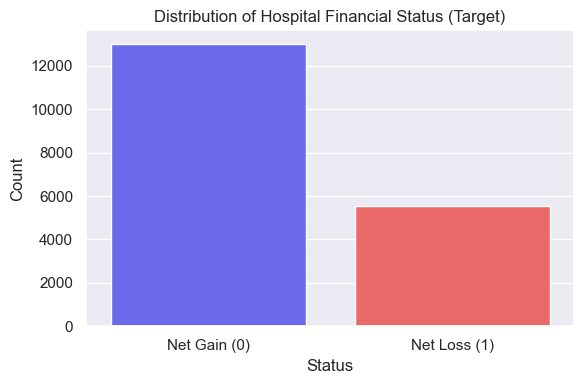

In [58]:
sns.set_theme(style='darkgrid')
mapping = {0: 'Net Gain (0)', 1: 'Net Loss (1)'}
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=data, x='financial_distress', hue='financial_distress', palette='seismic', formatter=mapping, legend=False)
ax.set(title='Distribution of Hospital Financial Status (Target)', xlabel='Status', ylabel='Count')
plt.tight_layout()
plt.show()

### Numerical Features Analysis

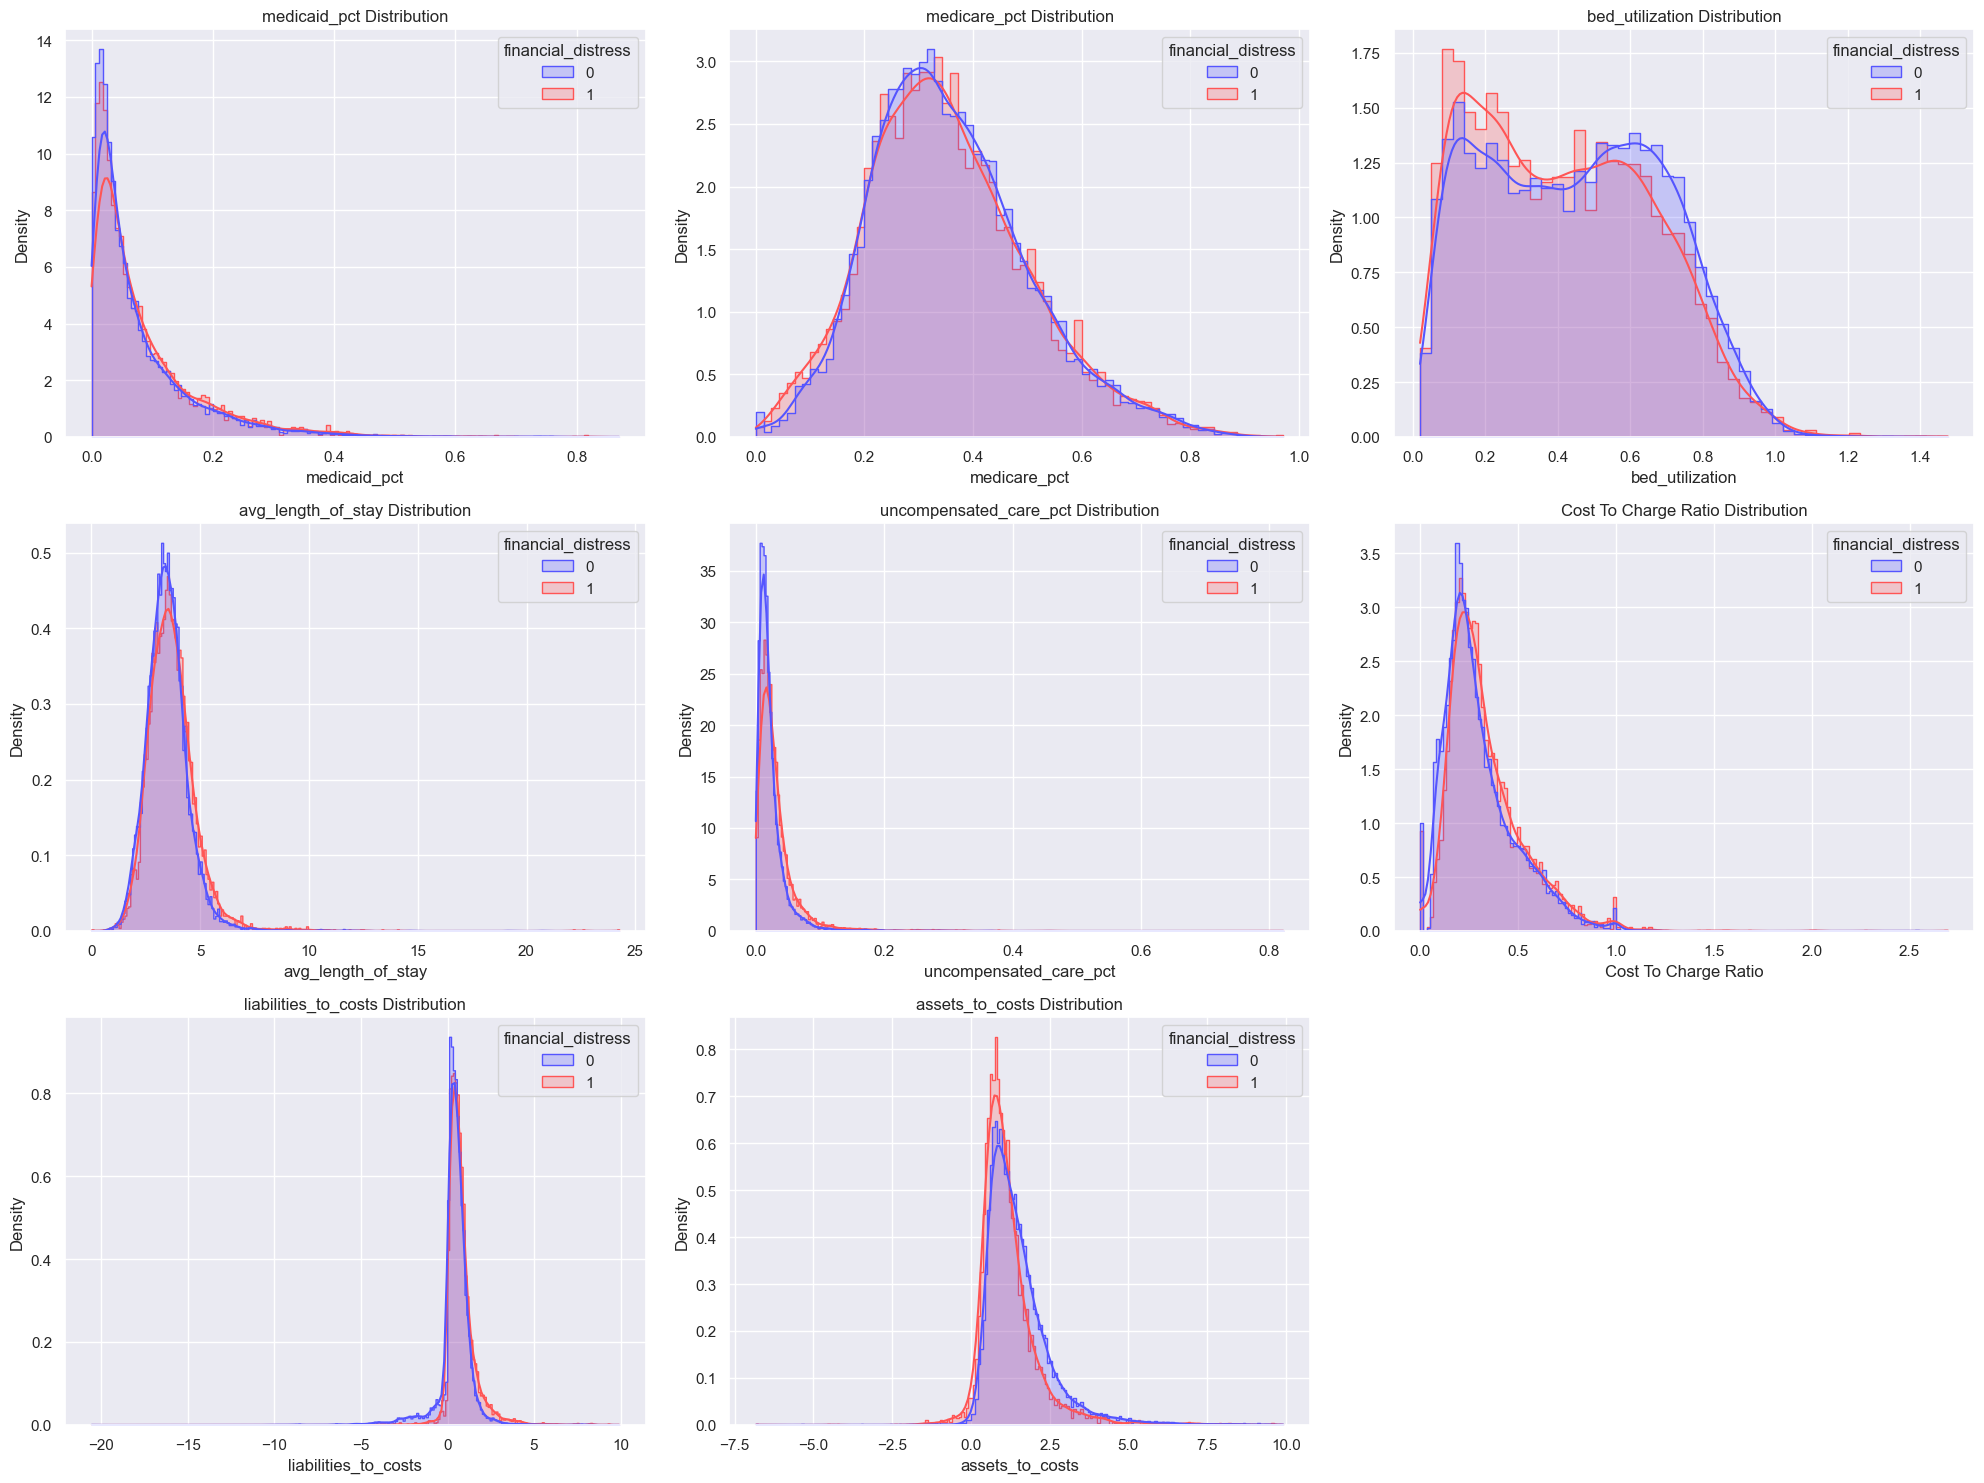

In [59]:
plt.figure(figsize=(20,15))

for i, col in enumerate(numeric_features):
    plt.subplot(3,3,i+1)
    sns.histplot(
        data=data,
        x=col,
        hue='financial_distress',
        kde=True,
        stat='density',
        common_norm=False,
        element='step',
        palette='seismic'
    )

    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

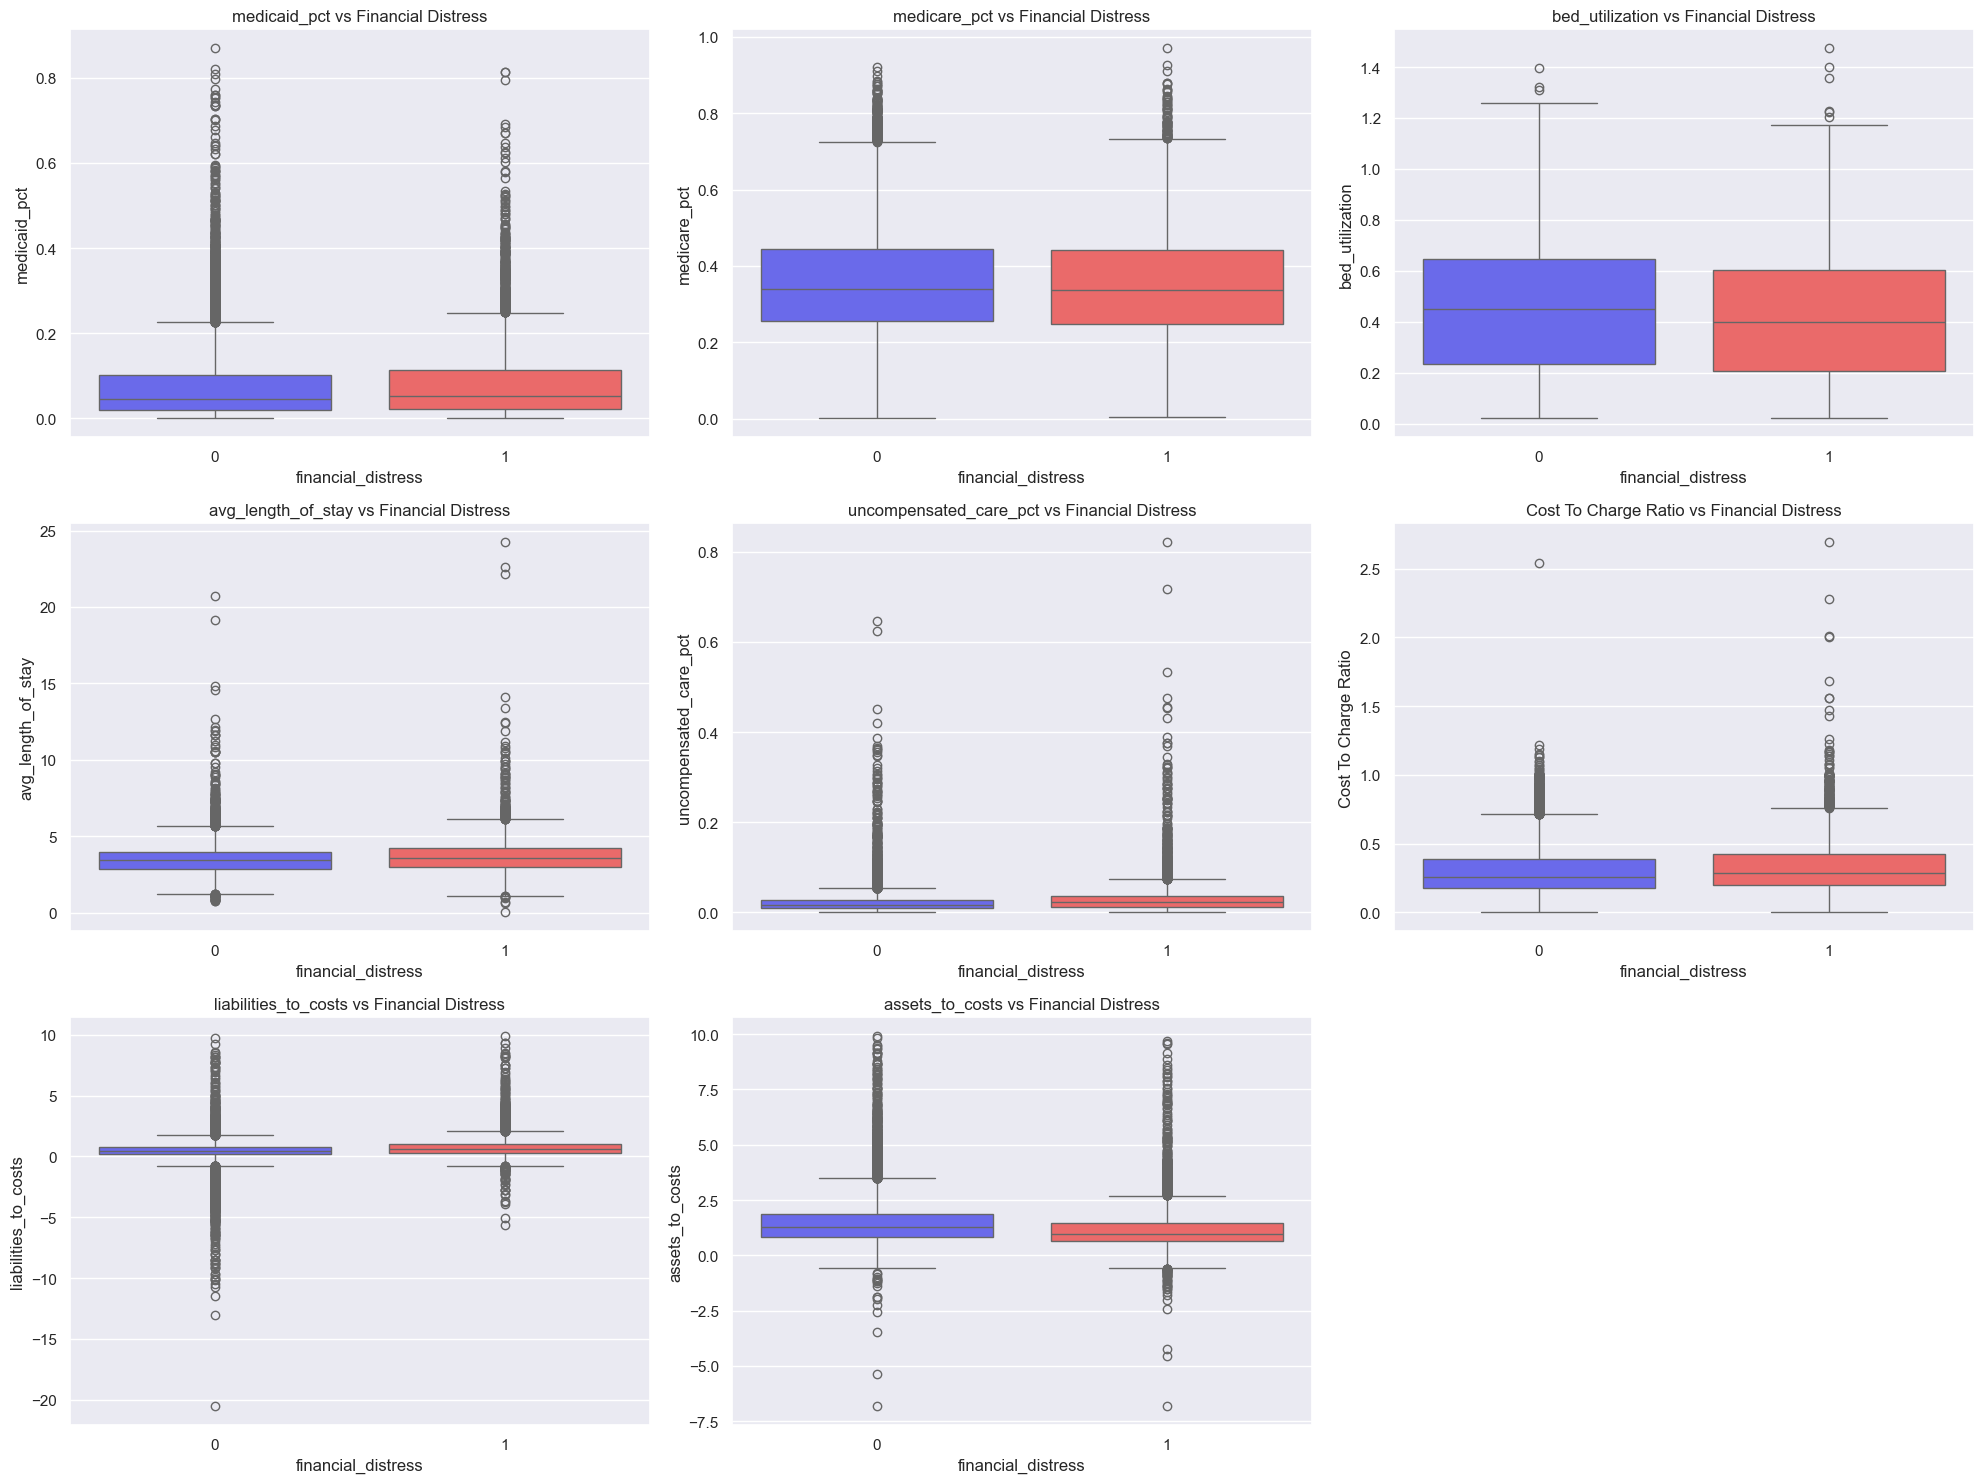

In [60]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(
        data=data,
        x='financial_distress',
        y=col,
        palette='seismic'
    )
    plt.title(f'{col} vs Financial Distress')

plt.tight_layout()
plt.show()

### Categorical Features Analysis

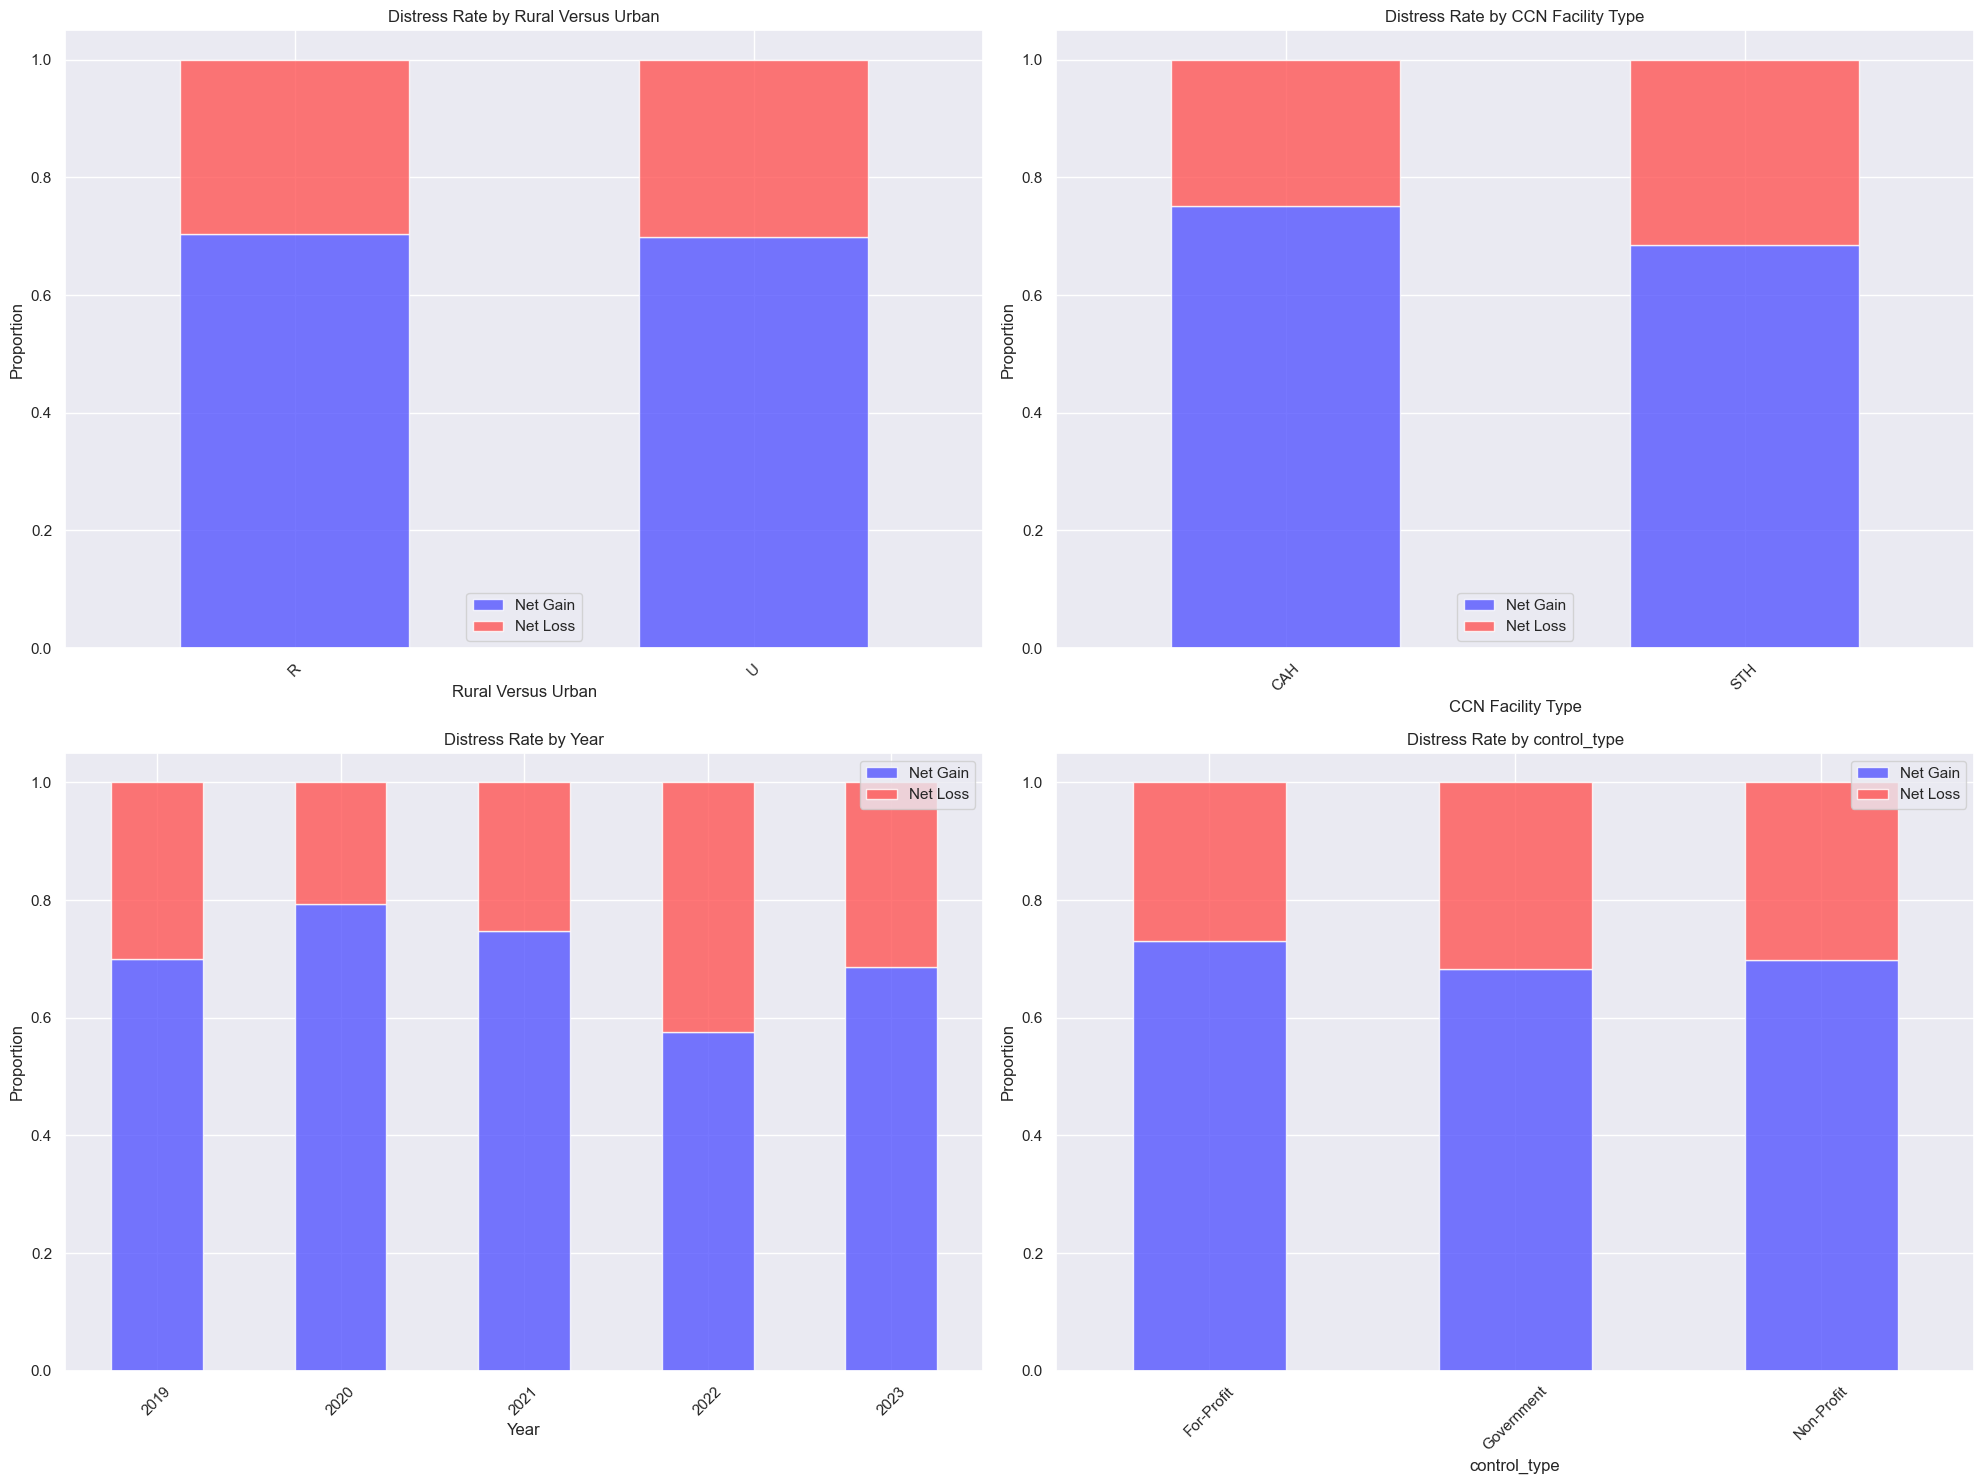

In [61]:

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()
colors = sns.color_palette('seismic', 2)

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(data[col], data['financial_distress'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, alpha=0.8)
    axes[i].set_title(f'Distress Rate by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['Net Gain', 'Net Loss'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Correlation Matrix

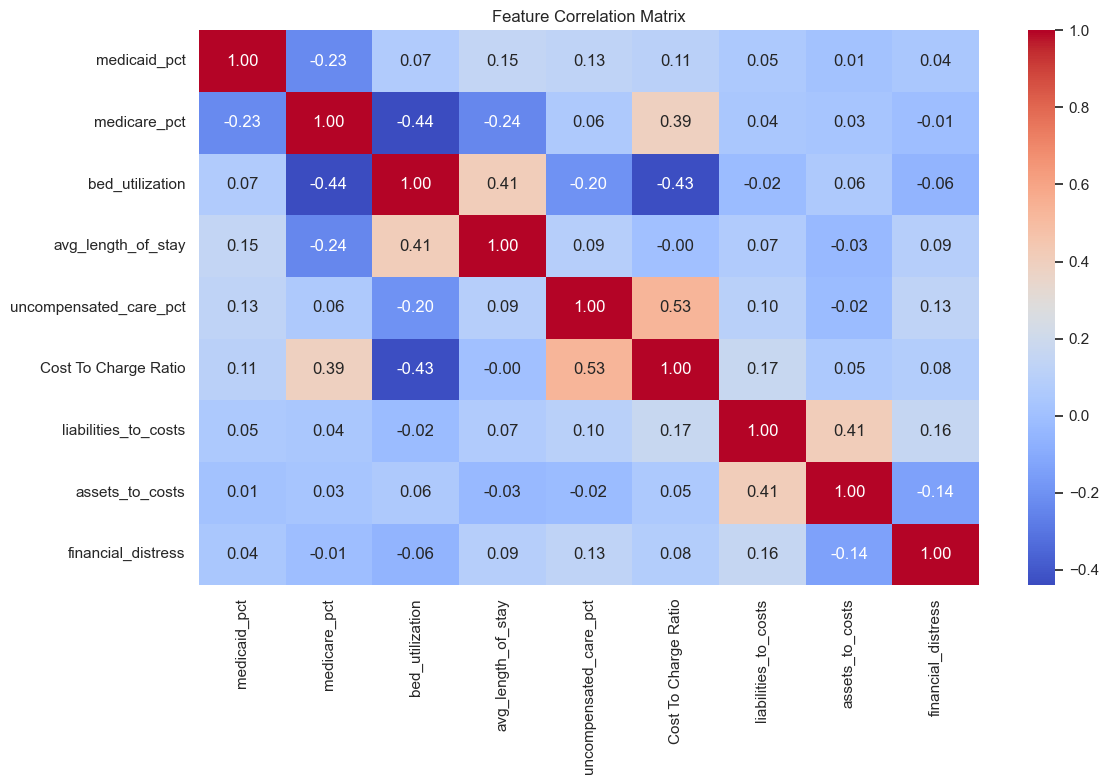

In [62]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(data[numeric_features + ["financial_distress"]].corr().round(2),
            annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Split Data

In [63]:
X_op = data[operational_numeric_features + categorical_features]
y = data['financial_distress']

X_train_op, X_test_op, y_train_op, y_test_op = train_test_split(X_op, y, test_size=0.2, random_state=42, stratify=y)

print(f'Operational         Training   Testing')
print(f'Sample Size:        {X_train_op.shape[0]}      {X_test_op.shape[0]}')
print(f'Distress Rates:     {y_train_op.mean():.3f}      {y_test_op.mean():.3f}')

Operational         Training   Testing
Sample Size:        14827      3707
Distress Rates:     0.299      0.299


In [64]:
X = data[numeric_features + categorical_features]
y = data['financial_distress']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'                   Training   Testing')
print(f'Sample Size:        {X_train.shape[0]}      {X_test.shape[0]}')
print(f'Distress Rates:     {y_train.mean():.3f}      {y_test.mean():.3f}')

                   Training   Testing
Sample Size:        14827      3707
Distress Rates:     0.299      0.299


### Operational Features Modeling
##### Grid search to identify optimal hyperparameters for RandomForestClassifier

In [65]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [5, 10, 15, 20, 25, 30, None],
    'classifier__min_samples_split': [5, 10, 15, 20],
    'classifier__max_features': ['sqrt', 'log2', 0.5]
}

rf_grid_op = GridSearchCV(
    Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers = [
                ('num', StandardScaler(), operational_numeric_features),
                ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
            ]
        )),
        ('classifier', RandomForestClassifier(
            random_state=42, class_weight='balanced', n_jobs=-1
        ))
    ]),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_grid_op.fit(X_train_op, y_train_op)

print('Operational Features: Random Forest Classifier')
print(f'Best recall: {rf_grid_op.best_score_:.4f}')
print(f'Best params: {rf_grid_op.best_params_}')

Operational Features: Random Forest Classifier
Best recall: 0.6001
Best params: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 10, 'classifier__n_estimators': 500}


In [66]:
y_pred_op = rf_grid_op.best_estimator_.predict(X_test_op)
y_proba_op = rf_grid_op.best_estimator_.predict_proba(X_test_op)[:, 1]

print('Operational Features: Random Forest Classifier')
print(classification_report(y_test_op, y_pred_op, target_names=['Net Gain', 'Net Loss']))
print(f'ROC-AUC: {roc_auc_score(y_test_op, y_proba_op):.4f}')
print(f'Accuracy: {accuracy_score(y_test_op, y_pred_op):.4f}')

Operational Features: Random Forest Classifier
              precision    recall  f1-score   support

    Net Gain       0.80      0.68      0.73      2598
    Net Loss       0.44      0.59      0.50      1109

    accuracy                           0.65      3707
   macro avg       0.62      0.63      0.62      3707
weighted avg       0.69      0.65      0.66      3707

ROC-AUC: 0.6780
Accuracy: 0.6525


##### Grid search to identify optimal hyperparameters for XGBoost

In [67]:
xgb_param_grid = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

scale_pos_weight_op = (y_train_op == 0).sum() / (y_train_op == 1).sum()

xgb_grid_op = GridSearchCV(
    Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), operational_numeric_features),
                ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
            ]
        )),
        ('classifier', XGBClassifier(
            random_state=42, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight_op
        ))
    ]),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

xgb_grid_op.fit(X_train_op, y_train_op)

print('Operational Features: XGBoost')
print(f'Best recall: {xgb_grid_op.best_score_:.4f}')
print(f'Best params: {xgb_grid_op.best_params_}')

Operational Features: XGBoost
Best recall: 0.6263
Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.7}


In [68]:
y_pred_xop = xgb_grid_op.best_estimator_.predict(X_test_op)
y_proba_xop = xgb_grid_op.best_estimator_.predict_proba(X_test_op)[:, 1]

print('Operational Features: XGBoost')
print(classification_report(y_test_op, y_pred_xop, target_names=['Net Gain', 'Net Loss']))
print(f'ROC-AUC: {roc_auc_score(y_test_op, y_proba_xop):.4f}')
print(f'Accuracy: {accuracy_score(y_test_op, y_pred_xop):.4f}')

Operational Features: XGBoost
              precision    recall  f1-score   support

    Net Gain       0.79      0.67      0.73      2598
    Net Loss       0.43      0.59      0.50      1109

    accuracy                           0.65      3707
   macro avg       0.61      0.63      0.61      3707
weighted avg       0.69      0.65      0.66      3707

ROC-AUC: 0.6897
Accuracy: 0.6463


### Operational & Financial Features Modeling
##### Grid search to identify optimal hyperparameters for RandomForestClassifier

In [69]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [5, 10, 15, 20, 25, 30, None],
    'classifier__min_samples_split': [5, 10, 15, 20],
    'classifier__max_features': ['sqrt', 'log2', 0.5]
}

rf_grid = GridSearchCV(
    Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers = [
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
            ]
        )),
        ('classifier', RandomForestClassifier(
            random_state=42, class_weight='balanced', n_jobs=-1
        ))
    ]),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f'Operational & Financial Features: Random Forest Classifier')
print(f'Best recall: {rf_grid.best_score_:.4f}')
print(f'Best params: {rf_grid.best_params_}')

Operational & Financial Features: Random Forest Classifier
Best recall: 0.7091
Best params: {'classifier__max_depth': 5, 'classifier__max_features': 0.5, 'classifier__min_samples_split': 15, 'classifier__n_estimators': 500}


In [70]:
y_pred = rf_grid.best_estimator_.predict(X_test)
y_proba = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]

print(f'Operational & Financial Features: Random Forest Classifier')
print(classification_report(y_test, y_pred, target_names=['Net Gain', 'Net Loss']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Operational & Financial Features: Random Forest Classifier
              precision    recall  f1-score   support

    Net Gain       0.84      0.66      0.74      2598
    Net Loss       0.47      0.70      0.56      1109

    accuracy                           0.67      3707
   macro avg       0.65      0.68      0.65      3707
weighted avg       0.73      0.67      0.69      3707

ROC-AUC: 0.7434
Accuracy: 0.6728


##### Grid search to identify optimal hyperparameters for XGBoost

In [71]:
xgb_param_grid = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_grid = GridSearchCV(
    Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
            ]
        )),
        ('classifier', XGBClassifier(
            random_state=42, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight
        ))
    ]),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print(f'Operational & Financial Features: XGBoost')
print(f'Best recall: {xgb_grid.best_score_:.4f}')
print(f'Best params: {xgb_grid.best_params_}')

Operational & Financial Features: XGBoost
Best recall: 0.7106
Best params: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.7}


In [72]:
y_pred = xgb_grid.best_estimator_.predict(X_test)
y_proba = xgb_grid.best_estimator_.predict_proba(X_test)[:, 1]

print(f'Operational & Financial Features: XGBoost')
print(classification_report(y_test, y_pred, target_names=['Net Gain', 'Net Loss']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Operational & Financial Features: XGBoost
              precision    recall  f1-score   support

    Net Gain       0.85      0.72      0.78      2598
    Net Loss       0.51      0.70      0.59      1109

    accuracy                           0.71      3707
   macro avg       0.68      0.71      0.68      3707
weighted avg       0.75      0.71      0.72      3707

ROC-AUC: 0.7774
Accuracy: 0.7097


### Model Explainability (SHAP)

In [73]:
# SHAP for XGBoost Best Model for Operational Features
best_model_op = xgb_grid_op.best_estimator_

X_train_transformed_op = best_model_op.named_steps['preprocessor'].transform(X_train_op)
X_test_transformed_op = best_model_op.named_steps['preprocessor'].transform(X_test_op)

explainer_op = shap.Explainer(best_model_op.named_steps['classifier'], X_train_transformed_op)
shap_values_op = explainer_op(X_test_transformed_op)

# SHAP for XGBoost Best Model for Operational & Financial features
best_model = xgb_grid.best_estimator_

X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

explainer = shap.Explainer(best_model.named_steps['classifier'], X_train_transformed)
shap_values = explainer(X_test_transformed)

Operational Features Impact Analysis


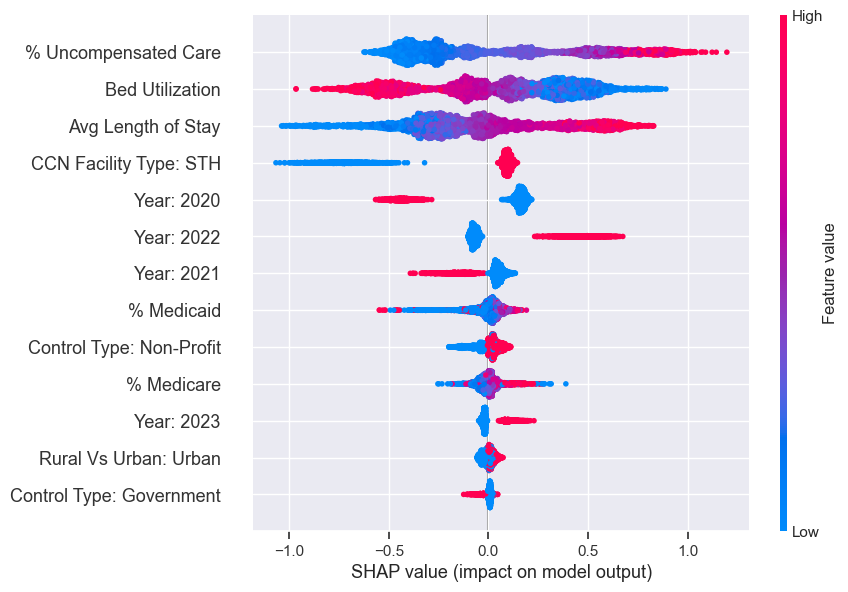


Operational & Financial Features Impact Analysis


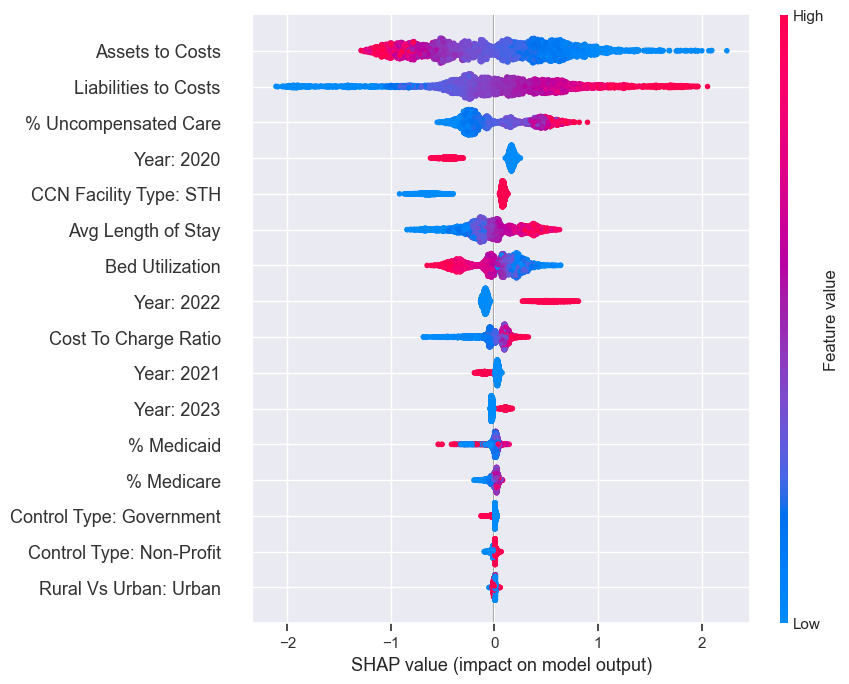

In [74]:
feature_name_mapping = {
    'medicare_pct': '% Medicare',
    'medicaid_pct': '% Medicaid',
    'avg_length_of_stay': 'Avg Length of Stay',
    'bed_utilization': 'Bed Utilization',
    'uncompensated_care_pct': '% Uncompensated Care',
    'CCN Facility Type_STH': 'CCN Facility Type: STH',
    'CCN Facility Type_CAH': 'CCN Facility Type: CAH',
    'control_type_Government': 'Control Type: Government',
    'control_type_Non-Profit': 'Control Type: Non-Profit',
    'control_type_For_Profit': 'Control Type: For-Profit',
    'Year_2019': 'Year: 2019',
    'Year_2020': 'Year: 2020',
    'Year_2021': 'Year: 2021', 
    'Year_2022': 'Year: 2022',
    'Year_2023': 'Year: 2023',
    'Rural Versus Urban_U': 'Rural Vs Urban: Urban',
    'Rural Versus Urban_R': 'Rural',
    'assets_to_costs': 'Assets to Costs',
    'liabilities_to_costs': 'Liabilities to Costs'
}
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_names_op = best_model_op.named_steps['preprocessor'].get_feature_names_out()

clean_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]
clean_names_op = [name.replace('num__', '').replace('cat__', '') for name in feature_names_op]

display_names = [feature_name_mapping.get(name, name) for name in clean_names]
display_names_op = [feature_name_mapping.get(name, name) for name in clean_names_op]

shap_values.feature_names = display_names
shap_values_op.feature_names = display_names_op

print(f'Operational Features Impact Analysis')
shap.plots.beeswarm(shap_values_op, max_display=15)
print()
print(f'Operational & Financial Features Impact Analysis')
shap.plots.beeswarm(shap_values, max_display=20)